## 0. Import Library

In [111]:
import os
import time
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
import keras
from keras import layers, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs('artifacts', exist_ok=True)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Input

Tahap awal: memuat data mentah (raw data). Dataset yang digunakan adalah UCI Epileptic Seizure Recognition Dataset, berisi 11.500 baris sinyal EEG dengan 178 titik data per sampel (kolom `X1`...`X178`) dan 1 kolom label `y` (nilai 1–5).

Keterangan label asli:
- y = 1 : kondisi epileptic seizure (kejang)
- y = 2 : mata terbuka (normal)
- y = 3 : mata tertutup (normal)
- y = 4 : EEG dari area otak sehat (normal)
- y = 5 : EEG dari area tumor otak (normal)

In [113]:
file_path = '/content/drive/MyDrive/UAS_ML PRAK/Epileptic_Seizure_Recognition.csv'
df = pd.read_csv(file_path)
print("Ukuran data:", df.shape)
df.head()


Ukuran data: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [114]:
print("Kolom pertama & terakhir:", df.columns[0], '...', df.columns[-1])
print("\nDistribusi kelas asli (5 kelas):")
print(df['y'].value_counts().sort_index())


Kolom pertama & terakhir: Unnamed ... y

Distribusi kelas asli (5 kelas):
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64


/tmp/ipykernel_2212/226949104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_5, y=counts.values, palette='viridis', ax=ax)


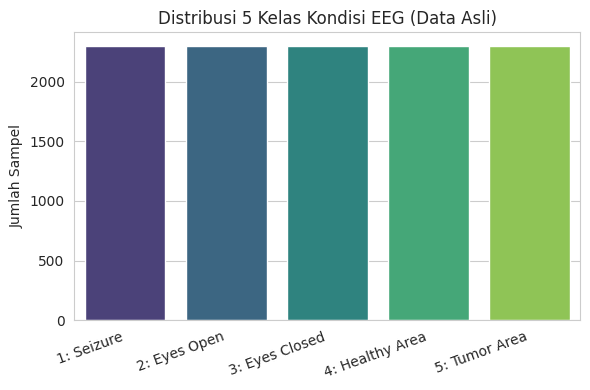

In [115]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df['y'].value_counts().sort_index()
labels_5 = ['1: Seizure', '2: Eyes Open', '3: Eyes Closed', '4: Healthy Area', '5: Tumor Area']
sns.barplot(x=labels_5, y=counts.values, palette='viridis', ax=ax)
ax.set_title('Distribusi 5 Kelas Kondisi EEG (Data Asli)')
ax.set_ylabel('Jumlah Sampel')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('artifacts/01_distribusi_5_kelas.png', dpi=120)
plt.show()


## 2. Preprocessing

Memeriksa missing value, duplikasi, dan gambaran umum sebaran nilai (outlier) sebelum ditransformasikan.


In [116]:
print("Jumlah missing value total:", df.isnull().sum().sum())
print("Jumlah baris duplikat:", df.duplicated().sum())
print("\nStatistik ringkas beberapa kolom fitur pertama:")
df.iloc[:, 1:6].describe()


Jumlah missing value total: 0
Jumlah baris duplikat: 0

Statistik ringkas beberapa kolom fitur pertama:


,X1,X2,X3,X4,X5
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739
std,165.626284,166.059609,163.524317,161.269041,160.998007
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000


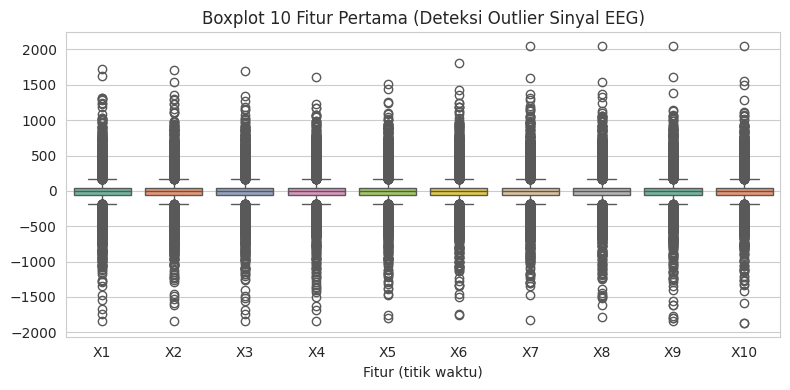

Catatan: nilai ekstrem pada sinyal EEG merupakan bagian natural dari amplitudo sinyal
(bukan noise/kesalahan input), sehingga tidak dilakukan penghapusan outlier di sini.


In [117]:
# Cek outlier secara visual pada beberapa fitur menggunakan boxplot
fig, ax = plt.subplots(figsize=(8,4))
sns.boxplot(data=df.iloc[:, 1:11], ax=ax, palette='Set2')
ax.set_title('Boxplot 10 Fitur Pertama (Deteksi Outlier Sinyal EEG)')
ax.set_xlabel('Fitur (titik waktu)')
plt.tight_layout()
plt.savefig('artifacts/02_boxplot_outlier.png', dpi=120)
plt.show()
print("Catatan: nilai ekstrem pada sinyal EEG merupakan bagian natural dari amplitudo sinyal")
print("(bukan noise/kesalahan input), sehingga tidak dilakukan penghapusan outlier di sini.")


### Distribusi Histogram 10 Fitur Pertama

Menampilkan sebaran nilai (histogram + KDE) dari 10 fitur pertama (`X1`-`X10`) untuk melihat bentuk distribusi masing-masing fitur sinyal EEG.

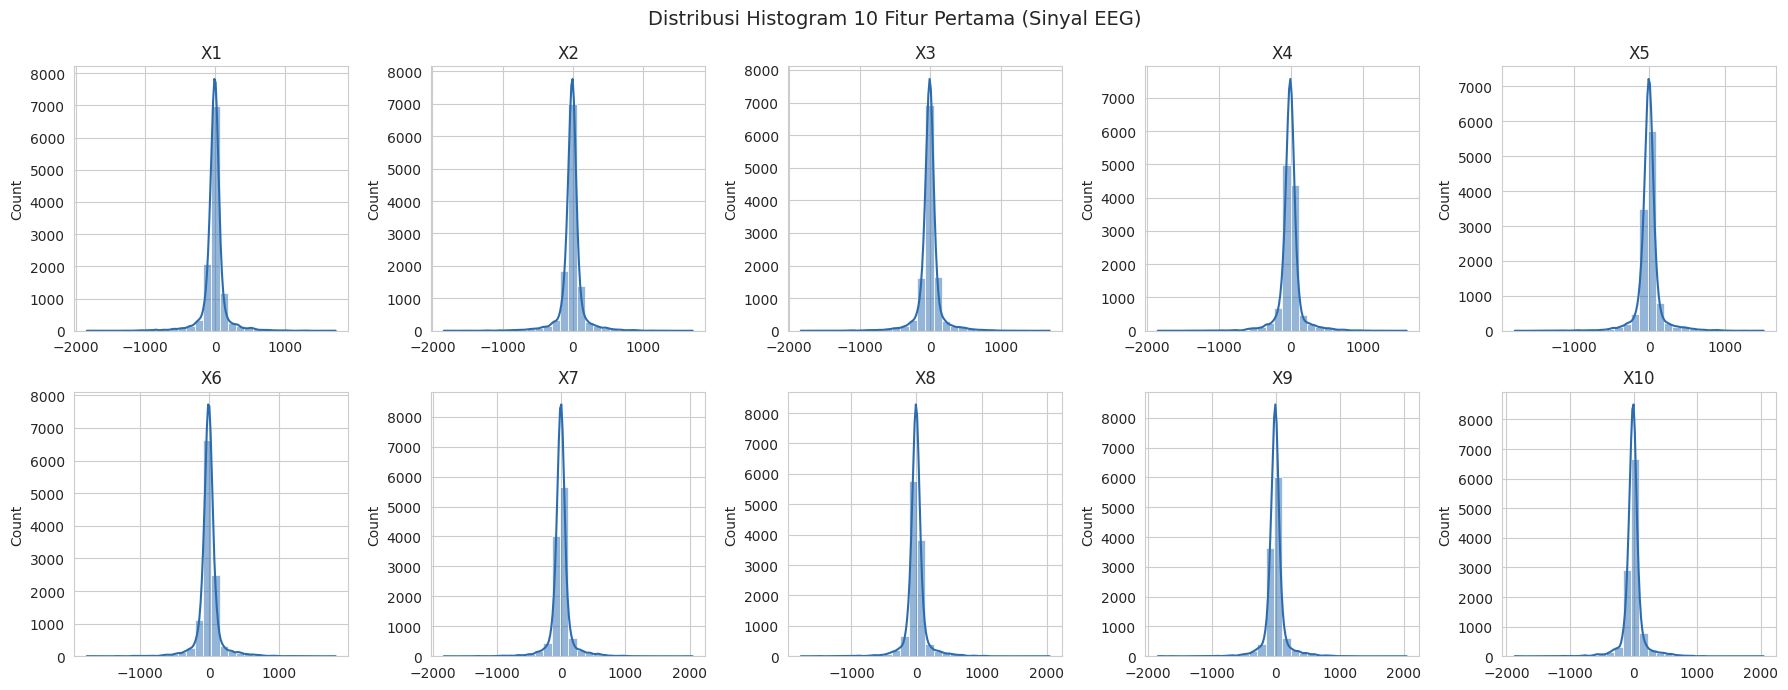

In [118]:
# Distribusi histogram 10 fitur pertama (X1-X10)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
fitur_10 = df.iloc[:, 1:11]
for i, col in enumerate(fitur_10.columns):
    sns.histplot(fitur_10[col], bins=30, kde=True, color='#2b6cb0', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

fig.suptitle('Distribusi Histogram 10 Fitur Pertama (Sinyal EEG)', fontsize=14)
plt.tight_layout()
plt.savefig('artifacts/02b_histogram_10_fitur_pertama.png', dpi=120)
plt.show()


## 3. Transformation

### 3.1 Membuat Label Biner
- Kelas 1 (Seizure) → label asli `y = 1`
- Kelas 0 (Non-Seizure) → gabungan label asli `y = 2, 3, 4, 5`


In [119]:
X_raw = df.drop(columns=['Unnamed', 'y']).values.astype('float32')
y_multiclass = df['y'].values

# Label biner: 1 = seizure, 0 = non-seizure (gabungan kelas 2-5)
y_binary = np.where(y_multiclass == 1, 1, 0)

print("Distribusi label biner:")
print(pd.Series(y_binary).value_counts().rename({1:'Seizure (1)', 0:'Non-Seizure (0)'}))


Distribusi label biner:
Non-Seizure (0)    9200
Seizure (1)        2300
Name: count, dtype: int64


/tmp/ipykernel_2212/707635981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Seizure (0)', 'Seizure (1)'], y=vc.values, palette=['#4C72B0','#DD8452'], ax=ax)


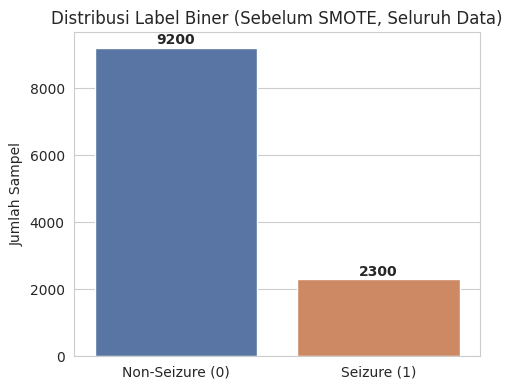

Rasio imbalance: 4.00 : 1 (Non-Seizure : Seizure)


In [120]:
fig, ax = plt.subplots(figsize=(5,4))
vc = pd.Series(y_binary).value_counts().sort_index()
sns.barplot(x=['Non-Seizure (0)', 'Seizure (1)'], y=vc.values, palette=['#4C72B0','#DD8452'], ax=ax)
for i, v in enumerate(vc.values):
    ax.text(i, v+100, str(v), ha='center', fontweight='bold')
ax.set_title('Distribusi Label Biner (Sebelum SMOTE, Seluruh Data)')
ax.set_ylabel('Jumlah Sampel')
plt.tight_layout()
plt.savefig('artifacts/03_distribusi_label_biner.png', dpi=120)
plt.show()
print(f"Rasio imbalance: {vc[0]/vc[1]:.2f} : 1 (Non-Seizure : Seizure)")


### 3.2 Ekstraksi Fitur — Downsampling (178 → 89 fitur)

Setiap sampel awalnya memiliki 178 titik data time-series (1 detik rekaman EEG, 178 Hz). Untuk mengurangi dimensi sekaligus mempertahankan pola bentuk sinyal, dilakukan downsampling dengan average pooling: setiap 2 titik waktu berdekatan (X1,X2), (X3,X4), ... dirata-rata menjadi 1 fitur baru, sehingga jumlah fitur berkurang dari 178 menjadi 89.

In [121]:
X_downsampled = X_raw.reshape(X_raw.shape[0], 89, 2).mean(axis=2)
print("Shape sebelum downsampling:", X_raw.shape)
print("Shape setelah downsampling :", X_downsampled.shape)


Shape sebelum downsampling: (11500, 178)
Shape setelah downsampling : (11500, 89)


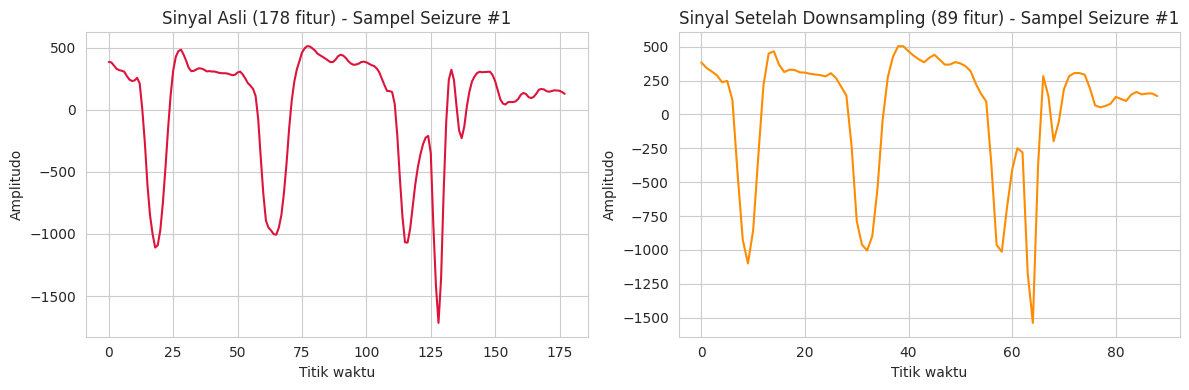

Bentuk pola sinyal (morfologi) tetap terjaga setelah downsampling.


In [122]:
# Visualisasi perbandingan sinyal sebelum vs sesudah downsampling untuk 1 sampel seizure
idx = np.where(y_binary == 1)[0][0]
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(X_raw[idx], color='crimson')
axes[0].set_title(f'Sinyal Asli (178 fitur) - Sampel Seizure #{idx}')
axes[0].set_xlabel('Titik waktu'); axes[0].set_ylabel('Amplitudo')

axes[1].plot(X_downsampled[idx], color='darkorange')
axes[1].set_title(f'Sinyal Setelah Downsampling (89 fitur) - Sampel Seizure #{idx}')
axes[1].set_xlabel('Titik waktu'); axes[1].set_ylabel('Amplitudo')
plt.tight_layout()
plt.savefig('artifacts/04_perbandingan_downsampling.png', dpi=120)
plt.show()
print("Bentuk pola sinyal (morfologi) tetap terjaga setelah downsampling.")


### 3.3 Scaling

Melakukan standarisasi (`StandardScaler`, mean=0, std=1) agar seluruh fitur berada dalam skala yang seragam sebelum masuk ke jaringan Deep Learning. Scaler di-fit hanya pada data training untuk mencegah data leakage, lalu diterapkan (transform) ke data validation dan testing.


## 4. Data Splitting (80% : 10% : 10%)

Dataset (hasil downsampling) dibagi menjadi tiga bagian dengan stratifikasi terhadap label biner agar proporsi kelas seizure/non-seizure tetap konsisten di setiap bagian:
- Training : 80%
- Validation : 10%
- Testing : 10%


In [123]:
# Split 1: 80% train, 20% sisa (temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_downsampled, y_binary, test_size=0.20, stratify=y_binary, random_state=SEED)

# Split 2: bagi 20% sisa menjadi 10% validation, 10% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Data Training   : {X_train.shape[0]:5d} sampel ({X_train.shape[0]/len(X_downsampled)*100:.1f}%)")
print(f"Data Validation : {X_val.shape[0]:5d} sampel ({X_val.shape[0]/len(X_downsampled)*100:.1f}%)")
print(f"Data Testing    : {X_test.shape[0]:5d} sampel ({X_test.shape[0]/len(X_downsampled)*100:.1f}%)")

split_summary = pd.DataFrame({
    'Split': ['Training', 'Validation', 'Testing'],
    'Jumlah Sampel': [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    'Non-Seizure (0)': [np.sum(y_train==0), np.sum(y_val==0), np.sum(y_test==0)],
    'Seizure (1)': [np.sum(y_train==1), np.sum(y_val==1), np.sum(y_test==1)],
})
split_summary


Data Training   :  9200 sampel (80.0%)
Data Validation :  1150 sampel (10.0%)
Data Testing    :  1150 sampel (10.0%)


,Split,Jumlah Sampel,Non-Seizure (0),Seizure (1)
0,Training,9200,7360,1840
1,Validation,1150,920,230
2,Testing,1150,920,230


In [124]:
# Scaling: fit hanya pada data training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Simpan scaler dan hasil split untuk digunakan kembali di notebook Bagian 2 (varian tanpa SMOTE)
with open('artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

np.savez('artifacts/data_splits.npz',
         X_train=X_train_scaled, y_train=y_train,
         X_val=X_val_scaled, y_val=y_val,
         X_test=X_test_scaled, y_test=y_test)

print("Scaler & data splits disimpan ke folder artifacts/ untuk konsistensi Bagian 2.")


Scaler & data splits disimpan ke folder artifacts/ untuk konsistensi Bagian 2.


## 5. Penanganan Imbalanced Data — SMOTE

Karena kelas Seizure (1) jauh lebih sedikit dibanding Non-Seizure (0) (rasio ±4:1), diterapkan SMOTE (Synthetic Minority Over-sampling Technique) untuk menyeimbangkan data. SMOTE hanya diterapkan pada data training (tidak pada validation/testing) agar evaluasi tetap merepresentasikan distribusi data asli di dunia nyata.


In [125]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE:", dict(pd.Series(y_train).value_counts().sort_index()))
print("Sesudah SMOTE :", dict(pd.Series(y_train_smote).value_counts().sort_index()))


Sebelum SMOTE: {0: np.int64(7360), 1: np.int64(1840)}
Sesudah SMOTE : {0: np.int64(7360), 1: np.int64(7360)}


/tmp/ipykernel_2212/1748676.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Seizure','Seizure'], y=before.values, palette=['#4C72B0','#DD8452'], ax=axes[0])
/tmp/ipykernel_2212/1748676.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Seizure','Seizure'], y=after.values, palette=['#4C72B0','#DD8452'], ax=axes[1])


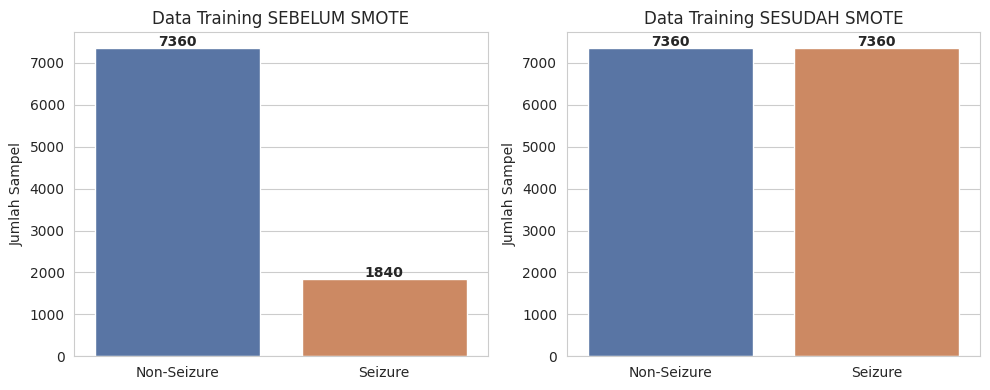

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_smote).value_counts().sort_index()

sns.barplot(x=['Non-Seizure','Seizure'], y=before.values, palette=['#4C72B0','#DD8452'], ax=axes[0])
axes[0].set_title('Data Training SEBELUM SMOTE')
axes[0].set_ylabel('Jumlah Sampel')
for i,v in enumerate(before.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

sns.barplot(x=['Non-Seizure','Seizure'], y=after.values, palette=['#4C72B0','#DD8452'], ax=axes[1])
axes[1].set_title('Data Training SESUDAH SMOTE')
axes[1].set_ylabel('Jumlah Sampel')
for i,v in enumerate(after.values):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/05_smote_before_after.png', dpi=120)
plt.show()


In [127]:
# Reshape ke bentuk 3D (samples, timesteps, channels) untuk input CNN/LSTM 1D
X_train_final = X_train_smote.reshape(-1, 89, 1)
X_val_final = X_val_scaled.reshape(-1, 89, 1)
X_test_final = X_test_scaled.reshape(-1, 89, 1)
y_train_final = y_train_smote

print("Shape input training (SMOTE) :", X_train_final.shape)
print("Shape input validation       :", X_val_final.shape)
print("Shape input testing          :", X_test_final.shape)


Shape input training (SMOTE) : (14720, 89, 1)
Shape input validation       : (1150, 89, 1)
Shape input testing          : (1150, 89, 1)


## 6. Klasifikasi — Deep Learning (Varian SMOTE)

Tiga arsitektur diuji pada data training hasil SMOTE:
1. CNN (1D Convolutional Neural Network)
2. LSTM (Long Short-Term Memory)
3. CNN-LSTM (Hybrid) — mengikuti arsitektur pada paper referensi (CNN untuk ekstraksi fitur spasial, dilanjutkan LSTM untuk menangkap pola temporal)

Setiap model dilatih menggunakan `EarlyStopping` (memantau `val_loss`) untuk mencegah overfitting dan mengembalikan bobot terbaik.


In [128]:
def build_cnn():
    model = keras.Sequential([
        layers.Input(shape=(89, 1)),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(64, 3, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_SMOTE')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_lstm():
    model = keras.Sequential([
        layers.Input(shape=(89, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='LSTM_SMOTE')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_lstm():
    model = keras.Sequential([
        layers.Input(shape=(89, 1)),
        layers.Conv1D(64, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu'),
        layers.MaxPooling1D(2),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='CNNLSTM_SMOTE')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def get_early_stop():
    return callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Dictionary penyimpanan hasil untuk keperluan evaluasi & komparasi
histories = {}
models = {}
metrics_summary = {}


### 6.1 Model CNN + SMOTE

In [129]:
model_cnn = build_cnn()
model_cnn.summary()


Model: "CNN_SMOTE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 87, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 18, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,825 (210.25 KB)

 Trainable params: 53,825 (210.25 KB)

 Non-trainable params: 0 (0.00 B)

In [130]:
t0 = time.time()
history_cnn = model_cnn.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val),
    epochs=60, batch_size=64,
    callbacks=[get_early_stop()], verbose=1)
print(f"\nWaktu training CNN: {time.time()-t0:.1f} detik, berhenti di epoch {len(history_cnn.history['loss'])}")

histories['CNN'] = history_cnn.history
models['CNN'] = model_cnn


Epoch 1/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8802 - loss: 0.2547 - val_accuracy: 0.8922 - val_loss: 0.2289
Epoch 2/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9491 - loss: 0.1435 - val_accuracy: 0.9574 - val_loss: 0.1069
Epoch 3/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9594 - loss: 0.1102 - val_accuracy: 0.9496 - val_loss: 0.1275
Epoch 4/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9638 - loss: 0.1000 - val_accuracy: 0.9522 - val_loss: 0.1258
Epoch 5/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9662 - loss: 0.0942 - val_accuracy: 0.9626 - val_loss: 0.1050
Epoch 6/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9675 - loss: 0.0887 - val_accuracy: 0.9591 - val_loss: 0.1161
Epoch 7/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9698 - loss: 0.0860 - val_accuracy: 0.9670 - val_loss: 0.0994
Epoch 8/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9717 - loss: 0.0795 - val_accuracy: 0.

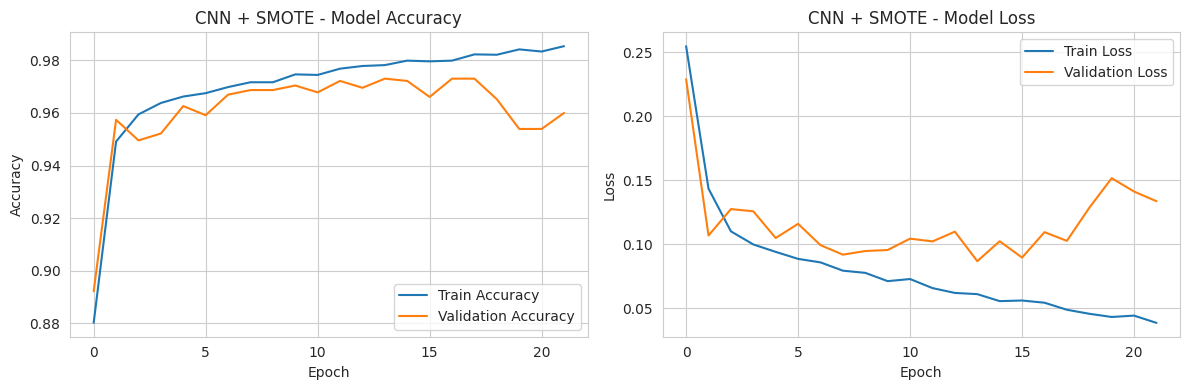

In [131]:
def plot_history(history, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history['accuracy'], label='Train Accuracy')
    axes[0].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} - Model Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

    axes[1].plot(history['loss'], label='Train Loss')
    axes[1].plot(history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} - Model Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()

plot_history(histories['CNN'], 'CNN + SMOTE', 'artifacts/06_cnn_smote_history.png')


### 6.2 Model LSTM + SMOTE

In [132]:
model_lstm = build_lstm()
model_lstm.summary()


Model: "LSTM_SMOTE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 89, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
t0 = time.time()
history_lstm = model_lstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val),
    epochs=60, batch_size=128,
    callbacks=[get_early_stop()], verbose=1)
print(f"\nWaktu training LSTM: {time.time()-t0:.1f} detik, berhenti di epoch {len(history_lstm.history['loss'])}")

histories['LSTM'] = history_lstm.history
models['LSTM'] = model_lstm


Epoch 1/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9005 - loss: 0.2884 - val_accuracy: 0.9400 - val_loss: 0.1452
Epoch 2/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9486 - loss: 0.1471 - val_accuracy: 0.9435 - val_loss: 0.1153
Epoch 3/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9531 - loss: 0.1319 - val_accuracy: 0.9417 - val_loss: 0.1219
Epoch 4/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9554 - loss: 0.1224 - val_accuracy: 0.9478 - val_loss: 0.1084
Epoch 5/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9579 - loss: 0.1158 - val_accuracy: 0.9513 - val_loss: 0.0969
Epoch 6/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9614 - loss: 0.1112 - val_accuracy: 0.9470 - val_loss: 0.1120
Epoch 7/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9608 - loss: 0.1058 - val_accuracy: 0.9504 - val_loss: 0.0983
Epoch 8/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9624 - loss: 0.1011 - val_accu

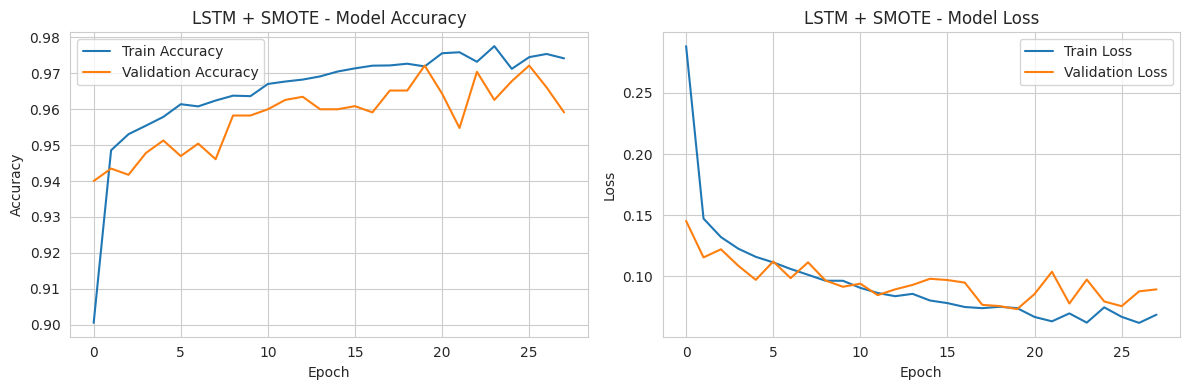

In [134]:
plot_history(histories['LSTM'], 'LSTM + SMOTE', 'artifacts/07_lstm_smote_history.png')


### 6.3 Model CNN-LSTM (Hybrid) + SMOTE

In [135]:
model_cnnlstm = build_cnn_lstm()
model_cnnlstm.summary()


Model: "CNNLSTM_SMOTE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 87, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,873 (343.25 KB)

 Trainable params: 87,873 (343.25 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
t0 = time.time()
history_cnnlstm = model_cnnlstm.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val),
    epochs=60, batch_size=64,
    callbacks=[get_early_stop()], verbose=1)
print(f"\nWaktu training CNN-LSTM: {time.time()-t0:.1f} detik, berhenti di epoch {len(history_cnnlstm.history['loss'])}")

histories['CNN+LSTM'] = history_cnnlstm.history
models['CNN+LSTM'] = model_cnnlstm


Epoch 1/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9183 - loss: 0.2044 - val_accuracy: 0.9583 - val_loss: 0.0994
Epoch 2/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9582 - loss: 0.1162 - val_accuracy: 0.9617 - val_loss: 0.0795
Epoch 3/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9641 - loss: 0.1004 - val_accuracy: 0.9626 - val_loss: 0.0849
Epoch 4/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9684 - loss: 0.0892 - val_accuracy: 0.9696 - val_loss: 0.0744
Epoch 5/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9720 - loss: 0.0797 - val_accuracy: 0.9643 - val_loss: 0.0906
Epoch 6/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9751 - loss: 0.0698 - val_accuracy: 0.9530 - val_loss: 0.1263
Epoch 7/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9766 - loss: 0.0626 - val_accuracy: 0.9704 - val_loss: 0.0745
Epoch 8/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9800 - loss: 0.0550 - val_accuracy

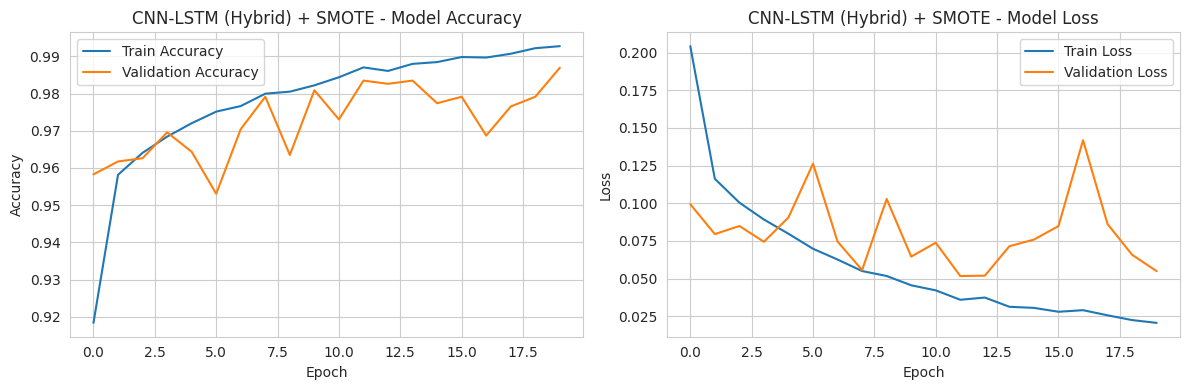

In [137]:
plot_history(histories['CNN+LSTM'], 'CNN-LSTM (Hybrid) + SMOTE', 'artifacts/08_cnnlstm_smote_history.png')


## 7. Evaluasi & Komparasi (Varian SMOTE)

Setiap model dievaluasi pada Data Testing (data yang belum pernah dilihat model selama training/validasi) menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, serta Confusion Matrix.


In [138]:
def evaluate_model(model, X_test, y_test, name):
    y_pred_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Non-Seizure','Seizure']))

    fig, ax = plt.subplots(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Seizure','Seizure'],
                yticklabels=['Non-Seizure','Seizure'], ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    plt.tight_layout()
    plt.savefig(f'artifacts/cm_{name.replace("+","").replace(" ","_")}.png', dpi=120)
    plt.show()

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1)


===== CNN + SMOTE =====
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.96      0.98       920
     Seizure       0.87      0.99      0.93       230

    accuracy                           0.97      1150
   macro avg       0.93      0.98      0.95      1150
weighted avg       0.97      0.97      0.97      1150



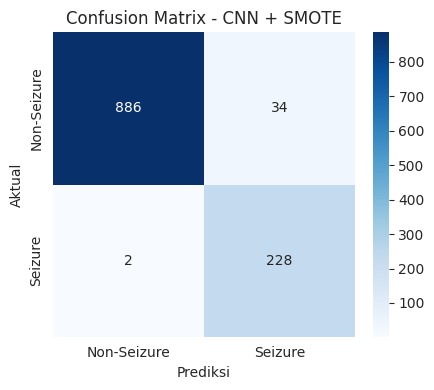

In [139]:
metrics_summary['CNN'] = evaluate_model(models['CNN'], X_test_final, y_test, 'CNN + SMOTE')


===== LSTM + SMOTE =====
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.97      0.98       920
     Seizure       0.90      0.99      0.94       230

    accuracy                           0.97      1150
   macro avg       0.95      0.98      0.96      1150
weighted avg       0.98      0.97      0.98      1150



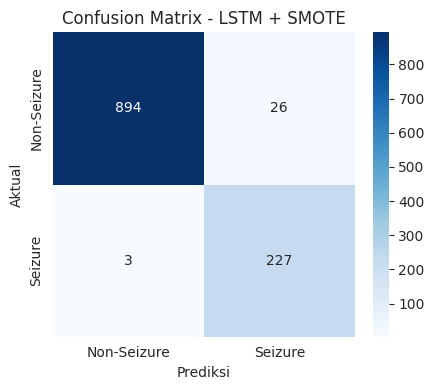

In [140]:
metrics_summary['LSTM'] = evaluate_model(models['LSTM'], X_test_final, y_test, 'LSTM + SMOTE')


===== CNN-LSTM + SMOTE =====
              precision    recall  f1-score   support

 Non-Seizure       1.00      0.98      0.99       920
     Seizure       0.93      1.00      0.96       230

    accuracy                           0.98      1150
   macro avg       0.96      0.99      0.98      1150
weighted avg       0.99      0.98      0.98      1150



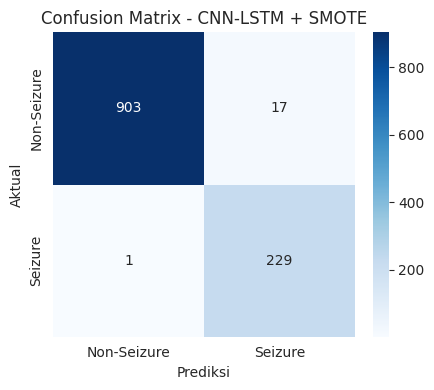

In [141]:
metrics_summary['CNN+LSTM'] = evaluate_model(models['CNN+LSTM'], X_test_final, y_test, 'CNN-LSTM + SMOTE')


### 7.1 Tabel Komparasi 3 Model (Varian SMOTE)

In [142]:
summary_df = pd.DataFrame(metrics_summary).T
summary_df = summary_df[['accuracy','precision','recall','f1']]
summary_df.columns = ['Accuracy','Precision','Recall','F1-Score']
summary_df = summary_df.round(4)
summary_df.index.name = 'Model (SMOTE)'
summary_df


,Accuracy,Precision,Recall,F1-Score
Model (SMOTE),,,,
CNN,0.9687,0.8702,0.9913,0.9268
LSTM,0.9748,0.8972,0.9870,0.9400
CNN+LSTM,0.9843,0.9309,0.9957,0.9622


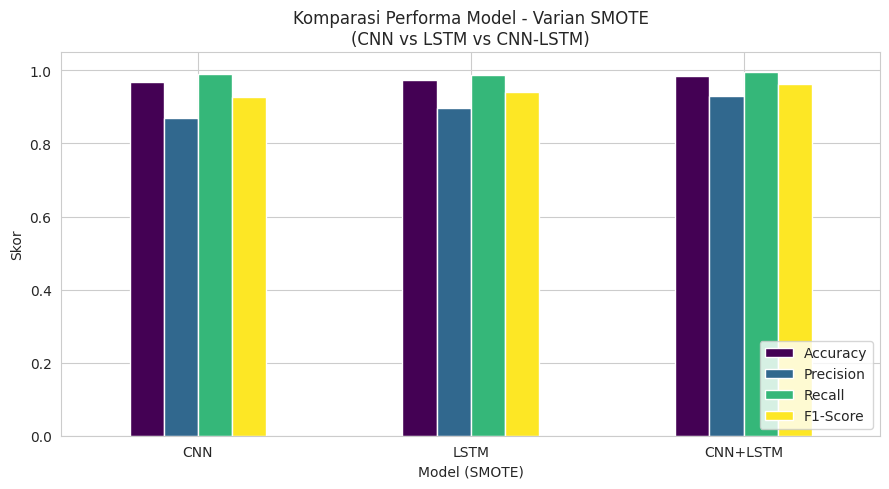


Model dengan akurasi tertinggi (varian SMOTE): CNN+LSTM (Accuracy = 0.9843)


In [143]:
fig, ax = plt.subplots(figsize=(9,5))
summary_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Komparasi Performa Model - Varian SMOTE\n(CNN vs LSTM vs CNN-LSTM)')
ax.set_ylabel('Skor')
ax.set_ylim(0,1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('artifacts/09_komparasi_3model_smote.png', dpi=120)
plt.show()

best_model = summary_df['Accuracy'].idxmax()
print(f"\nModel dengan akurasi tertinggi (varian SMOTE): {best_model} "
      f"(Accuracy = {summary_df.loc[best_model,'Accuracy']:.4f})")


## 8. Menyimpan Model & Artefak


In [144]:
for name, model in models.items():
    fname = f"artifacts/model_{name.replace('+','').replace(' ','_')}_smote.keras"
    model.save(fname)
    print("Tersimpan:", fname)

with open('artifacts/history_smote.json', 'w') as f:
    json.dump({k: {kk: [float(x) for x in vv] for kk, vv in v.items()} for k, v in histories.items()}, f, indent=2)

with open('artifacts/metrics_smote.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

Tersimpan: artifacts/model_CNN_smote.keras
Tersimpan: artifacts/model_LSTM_smote.keras
Tersimpan: artifacts/model_CNNLSTM_smote.keras
